# Exploring soil modeling in soilice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice import model

In [3]:
from matplotlib.gridspec import GridSpec

In [4]:
from soilice.src_constitutiveFunctions import KFun
from soilice.src_soil import MakeDictFloat

In [5]:
def profilePlot(out,xl=[-1.2,0,0.4,0.6,-2.5,2.5],popt=0.):
    t,qI,qT,qB,thetaL,thetaI,psie,psif,T,title = (
        out.t,
        out.qI,
        out.qT,
        out.qB,
        out.thetaL,
        out.thetaI,
        out.psie,
        out.psif,
        out.T,
        out.title
    )
    i=np.arange(0,len(t),5)
    n_lines = len(i)
    cmap = pl.cm.viridis_r
    cmap2 = pl.cm.autumn_r
    cmap3 = pl.cm.cool
    
    # i=np.array([0,len(t)-1])
    
    # --- Create figure and layout ---
    fig = pl.figure(figsize=(9,4))
    gs = GridSpec(1, 4, figure=fig)
    
    ax1 = fig.add_subplot(gs[:, 1])
    ax2 = fig.add_subplot(gs[:, 0])
    ax3 = fig.add_subplot(gs[:, 2])
    ax4 = fig.add_subplot(gs[:, 3])
    
    # --- Left plot (potentials) ---
    # ax2.plot(psif[0,:].T, z, 'c', label='Frozen potential')
    # ax2.plot(psie[0,:].T, z, 'b', label='Matric potential')
    count=0
    for j in i:
        color = cmap(count / (n_lines - 1))
        count+=1
        if popt:
            ax2.plot(psif[j,:].T, z, color=color)
        else:
            ax2.plot(psie[j,:].T, z, color=color)
    # line_h, = ax2.plot([], [], 'g', label='Hydraulic head')
    line_h, = ax2.plot([], [], 'g')
    ax2.set_ylim(1, 0)
    # ax2.set_xlim(xl[0],xl[1])
    ax2.set_xlabel('Matric potential (m)')
    ax2.set_ylabel('Depth (m)')
    # ax2.legend(loc=1)
    ax2.grid()

    # plot K profile:

    pars=MakeDictFloat()
    for key in sim.pars: pars[key]=sim.pars[key]
    const=MakeDictFloat()
    for key in sim.const: const[key]=sim.const[key]
    count=0
    for j in i:
        if popt:
            K=KFun(out.psif[j,:],out.psif[j,:],pars,const)
        else:
            K=KFun(out.psie[j,:],out.psif[j,:],pars,const)
        
        color = cmap(count / (n_lines - 1))
        count+=1
        if popt:
            ax1.plot(K.T, z, color=color)
            ax1.set_xlim(1e-12,1e-2)
        else:
            ax1.plot(K.T, z, color=color)
            ax1.set_xlim(1e-4,1e-2)
    ax1.set_ylim(1, 0)
    
    ax1.set_xlabel('K (m/d)')
    ax1.set_ylabel('Depth (m)')
    ax1.set_xscale('log')
    # ax2.legend(loc=1)
    ax1.set_yticklabels([])
    ax1.grid()
        
    
    # --- Middle plot (water content) ---
    count=0
    for j in i:
        color2 = cmap2(count / (n_lines - 1))
        color3 = cmap3(count / (n_lines - 1))
        count+=1
    # ax2.plot(psif[i,:].T, z, 'c')
        ax3.plot(thetaL[j,:].T, z, color=color2)
        ax3.plot(thetaI[j,:].T, z, color=color3)
        # ax3.plot(thetaL[0,:].T, z, 'b', label='Liquid')
    # ax3.plot(thetaI[0,:].T, z, 'c', label='Ice')
    # ax3.plot(thetaL[i,:].T, z, 'b')
    # ax3.plot(thetaI[i,:].T, z, 'c')
    
    ax3.set_ylim(1, 0)
    ax3.set_xlim(xl[2],xl[3])
    ax3.set_yticklabels([])
    ax3.set_xlabel('Water content (-)')
    # ax3.legend(loc=1)
    ax3.grid()
    
    # --- Right plot (temperature) ---
    count=0
    for j in i:
        color = cmap(count / (n_lines - 1))
        count+=1
    # ax2.plot(psif[i,:].T, z, 'c')
        ax4.plot(T[j,:].T, z, color=color)
    # ax4.plot(T[i,:].T, z, 'r', label='Temperature')
    ax4.set_ylim(1, 0)
    ax4.set_xlim(xl[4],xl[5])
    ax4.set_yticklabels([])
    ax4.set_xlabel('Temperature (°C)')
    ax4.grid()
    
    # --- Adjust spacing ---
    pl.subplots_adjust(wspace=0.05, hspace=0.4,bottom=0.13)
    
    fig.suptitle(title)

In [6]:
# x=model()
# x.setOpts()
# x.opts

In [7]:
# Soil model options:
opts={'simulateFlow': 1.0,    # simulate flow
 'gravity': 1.0,              # vertical flow
 'infiltration': 1.0,         # potential infiltration type upper BC
 'cryoK': 0.0,                # K based on total water content
 'cryoGradient': 0.0,             # Not using cryosuction for gradient 
 'freeDrainage': 0.0,         # No flow lower BC
 'simulateTransport': 1.0,    # simulate heat transport
 'withadv': 1.0,              # include advection
 'conductionTop': 1.0,        # Conduction on upper BC
 'conductionBot': 1.0}        # and lower BC

In [8]:
# Space grid
zMax=1.
dz=0.001
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

# Time grid
t=np.arange(0,10,0.02) # days
nt=len(t)
dt=t[1]-t[0]

In [9]:
sim=model(opts,rtol=1e-8)
sim.zGrid(np.hstack([0,np.cumsum(dz)]))
sim.tGrid(t[0],t[-1],t[1]-t[0])
sim.readPars()

In [10]:
# Run first scenario
opts['cryoK']=1.                 # K based on psif 
opts['cryoGradient']=0.              # 0. flow based on psie; 1. flow based on psif 
sim.opts=opts
sim.setBCs(TTop=1,TBot=1)
sim.setICs(psi0=-2,T0=1)
sim.printOpts()
out=sim.run()
out.title=f"Unfrozen gravity redistribution"

*************************************************************************
     SUMMARY OF MODEL OPTIONS:
     * Simulating flow
     * Vertical flow
     * Infiltration at ground surface
     * Hydraulic conductivity based on liquid water content
     * No cryosuction
     * No (mass) flow lower boundary condition
     * Simulating heat transport
     * Included heat advection
     * Conduction on the upper boundary
     * Conduction on the lower boundary
*************************************************************************


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l 

*************************************************************************
     soilice ran successfully!
               runtime:      13.27 seconds


     Mass balance rmse:  2.51e-05 kg
                  bias:  3.49e-05 kg
   Energy balance rmse:  1.05e-01 J
                  bias:  1.46e-01 J
*************************************************************************



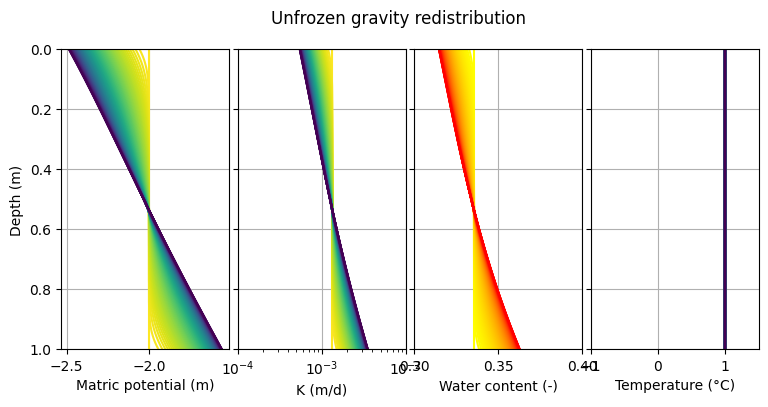

In [11]:
profilePlot(out,xl=[-3,-1,0.3,0.4,-1,1.5],popt=opts['cryoGradient'])
pl.savefig('figures/04_cryo01.svg')

*************************************************************************
     SUMMARY OF MODEL OPTIONS:
     * Simulating flow
     * Vertical flow
     * Infiltration at ground surface
     * Hydraulic conductivity based on liquid water content
     * No cryosuction
     * No (mass) flow lower boundary condition
     * Simulating heat transport
     * Included heat advection
     * Conduction on the upper boundary
     * Conduction on the lower boundary
*************************************************************************


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l 

*************************************************************************
     soilice ran successfully!
               runtime:      7.20 seconds
     Mass balance rmse:  1.23e-06 kg
                  bias: -1.39e-06 kg
   Energy balance rmse:  1.18e+01 J
                  bias:  1.83e+01 J
*************************************************************************



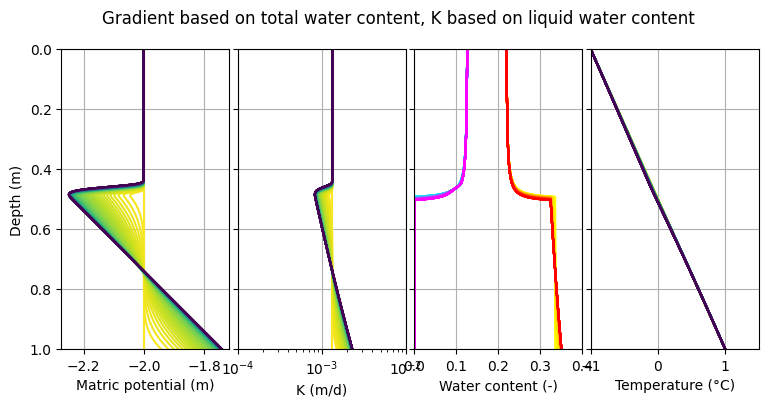

In [12]:
# Run 2nd scenario
opts['cryoK']=1.                 # K based on psif 
opts['cryoGradient']=0.              # gradient based on psie
sim.opts=opts
sim.setBCs(TTop=-1,TBot=1)
sim.setICs(psi0=-2,T0=[-1,1])
sim.printOpts()
out=sim.run()
out.title=f"Gradient based on total water content, K based on liquid water content"

profilePlot(out,xl=[-3,-1,0.,0.4,-1,1.5],popt=opts['cryoGradient'])
pl.savefig('figures/04_cryo02.svg')

*************************************************************************
     SUMMARY OF MODEL OPTIONS:
     * Simulating flow
     * Vertical flow
     * Infiltration at ground surface
     * Hydraulic conductivity based on liquid water content
     * Uses cryosuction based gradient
     * No (mass) flow lower boundary condition
     * Simulating heat transport
     * Included heat advection
     * Conduction on the upper boundary
     * Conduction on the lower boundary
*************************************************************************


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::

*************************************************************************
     soilice ran successfully!
               runtime:      13.84 seconds
     Mass balance rmse:  9.04e-06 kg
                  bias: -1.12e-05 kg
   Energy balance rmse:  6.49e+01 J
                  bias:  8.21e+01 J
*************************************************************************



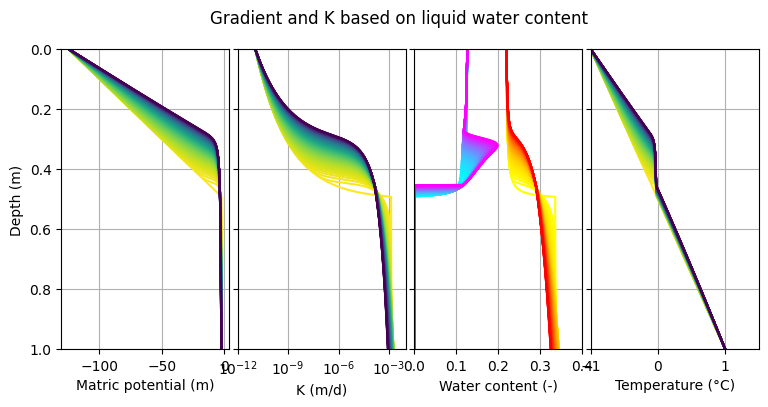

In [13]:
# Run 3rd scenario
opts['cryoK']=1.                 # K based on psif 
opts['cryoGradient']=1.              # gradient based on psif
sim.opts=opts
sim.setBCs(TTop=-1,TBot=1)
sim.setICs(psi0=-2,T0=[-1,1])
sim.printOpts()
out=sim.run()
out.title=f"Gradient and K based on liquid water content"

profilePlot(out,xl=[-5,0,0.,0.4,-1,1.5],popt=opts['cryoGradient'])
pl.savefig('figures/04_cryo03.svg')